<a href="https://colab.research.google.com/github/sairas2124/Gradient_descent-/blob/main/fer-2013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub
import pandas as pd
import os

# Download latest version of a dataset known to contain fer2013.csv
df_path = kagglehub.dataset_download("nicolejyt/facialexpressionrecognition")

# Search for fer2013.csv within the downloaded directory structure
csv_file_found = False
for root, dirs, files in os.walk(df_path):
    if "fer2013.csv" in files:
        csv_full_path = os.path.join(root, "fer2013.csv")
        df = pd.read_csv(csv_full_path)
        csv_file_found = True
        print(f"Found fer2013.csv at: {csv_full_path}")
        print("DataFrame loaded successfully. Shape:", df.shape)
        break

if not csv_file_found:
    print(f"Error: fer2013.csv not found in {df_path} or its subdirectories.")
    print("Contents of the downloaded path:", os.listdir(df_path))

print("Path to dataset files root:", df_path)

Using Colab cache for faster access to the 'facialexpressionrecognition' dataset.
Found fer2013.csv at: /kaggle/input/facialexpressionrecognition/fer2013.csv
DataFrame loaded successfully. Shape: (35887, 3)
Path to dataset files root: /kaggle/input/facialexpressionrecognition


In [ ]:
"""
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(csv_full_path)

# Convert pixels
def process_pixels(pixels):
    img = np.array(pixels.split(), dtype='float32')
    return img.reshape(48, 48)

df['image'] = df['pixels'].apply(process_pixels)

# Split
train_df = df[df['Usage'] == 'Training']
val_df = df[df['Usage'] == 'PublicTest']

# =========================
# AUGMENTATION (KEY 🔥)
# =========================
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

# =========================
# DATASET CLASS
# =========================
class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.images = df['image'].values
        self.labels = df['emotion'].values
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = np.uint8(img)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx])
        return img, label

train_dataset = FERDataset(train_df, train_transform)
val_dataset = FERDataset(val_df, val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# =========================
# IMPROVED CNN MODEL
# =========================
class EmotionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# =========================
# TRAIN SETUP
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = EmotionCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

# =========================
# TRAIN LOOP
# =========================
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss:", total_loss / len(train_loader))

# =========================
# EVALUATION
# =========================
model.eval()
preds = []
true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        pred = torch.argmax(outputs, dim=1)

        preds.extend(pred.cpu().numpy())
        true.extend(labels.numpy())

print("Validation Accuracy:", accuracy_score(true, preds))

# =========================
# SAVE MODEL
# =========================
torch.save(model.state_dict(), "/content/fer_model.pth")
"""

100%|██████████| 449/449 [00:13<00:00, 34.30it/s]


Epoch 0 Loss: 1.6778986878809259


100%|██████████| 449/449 [00:11<00:00, 38.77it/s]


Epoch 1 Loss: 1.512459682727975


100%|██████████| 449/449 [00:11<00:00, 38.51it/s]


...

Epoch 7 Loss: 1.3159234964502415


100%|██████████| 449/449 [00:11<00:00, 37.75it/s]


Epoch 8 Loss: 1.3044698288817713


100%|██████████| 449/449 [00:11<00:00, 37.88it/s]


Epoch 9 Loss: 1.2857535932802144
Validation Accuracy: 0.5371969908052382


Device: cuda
GPU: Tesla T4
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64
Train: 28709 Val: 3589 Test: 3589
Class weights: tensor([1.0266, 9.4066, 1.0010, 0.5684, 0.8491, 1.2934, 0.8260],
       device='cuda:0')
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]



Epoch 1/15


Train Loss: 0.9992 | Train Acc: 0.3688
Val   Loss: 1.7248 | Val   Acc: 0.4288
Best model saved.

Epoch 2/15


Train Loss: 0.7910 | Train Acc: 0.5218
Val   Loss: 1.6349 | Val   Acc: 0.5054
Best model saved.

Epoch 3/15


...

Train Loss: 0.5659 | Train Acc: 0.7654
Val   Loss: 1.5361 | Val   Acc: 0.6135
Best model saved.

Epoch 12/15


Train Loss: 0.5674 | Train Acc: 0.7798
Val   Loss: 1.5461 | Val   Acc: 0.6085
No improvement. Early stop counter: 1/4

Epoch 13/15


Train Loss: 0.5479 | Train Acc: 0.7926
Val   Loss: 1.5389 | Val   Acc: 0.6199
Best model saved.

Epoch 14/15


Train Loss: 0.5428 | Train Acc: 0.8055
Val   Loss: 1.5590 | Val   Acc: 0.6227
Best model saved.

Epoch 15/15


Train Loss: 0.5218 | Train Acc: 0.8232
Val   Loss: 1.5505 | Val   Acc: 0.6163
No improvement. Early stop counter: 1/4

Best Validation Accuracy: 0.6227

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.56      0.55      0.56       467
           1       0.21      0.71      0.33        56
           2       0.48      0.49      0.48       496
           3       0.88      0.80      0.84       895
           4       0.56      0.44      0.49       653
           5       0.76      0.79      0.77       415
           6       0.53      0.61      0.57       607

    accuracy                           0.62      3589
   macro avg       0.57      0.63      0.58      3589
weighted avg       0.64      0.62      0.63      3589



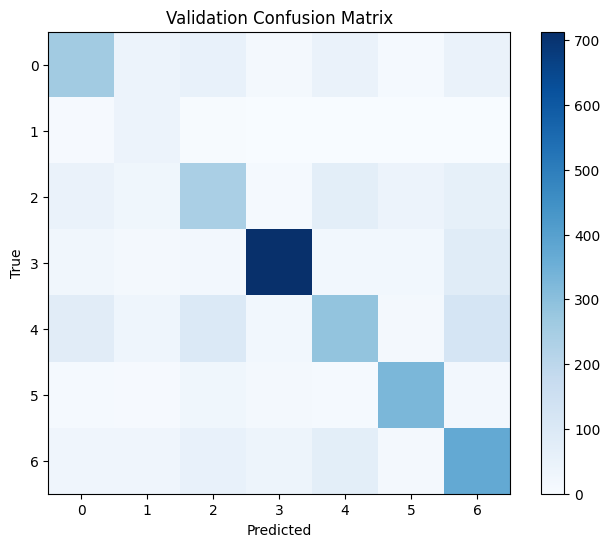


Private Test Accuracy: 0.6464

Classification Report (Private Test):
              precision    recall  f1-score   support

           0       0.58      0.55      0.57       491
           1       0.25      0.80      0.38        55
           2       0.51      0.52      0.51       528
           3       0.88      0.85      0.86       879
           4       0.55      0.43      0.48       594
           5       0.78      0.76      0.77       416
           6       0.60      0.66      0.63       626

    accuracy                           0.65      3589
   macro avg       0.59      0.65      0.60      3589
weighted avg       0.66      0.65      0.65      3589



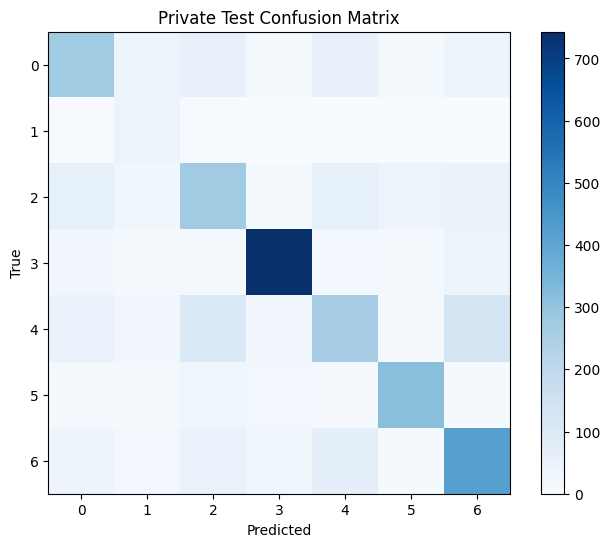

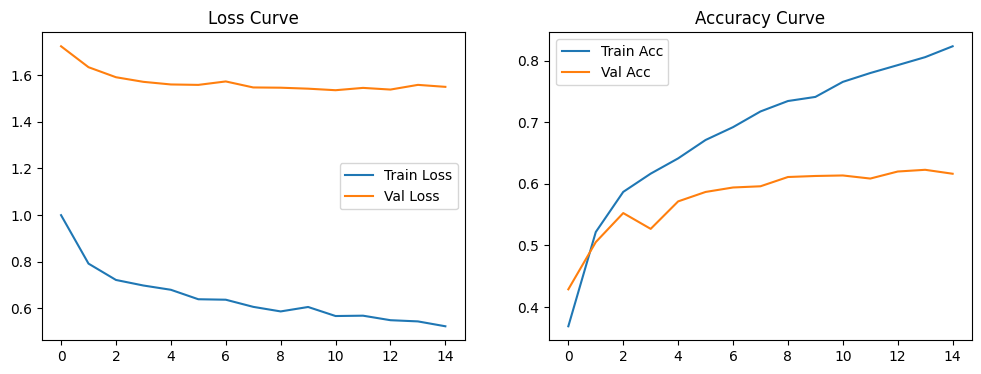

{0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
True Label: Angry
Predicted : Angry
Confidence: 0.496


In [6]:

# =========================================
# 3. IMPORTS
# =========================================
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
from PIL import Image

# =========================================
# 4. DEVICE
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================================
# 5. LOAD CSV
# =========================================
df = pd.read_csv(csv_full_path)
print(df.head())
print(df["Usage"].value_counts())
print(df["emotion"].value_counts())

# =========================================
# 6. CONVERT CSV PIXELS TO ARRAY
# =========================================
def pixels_to_image(pixel_string):
    pixels = np.array(pixel_string.split(), dtype=np.uint8)
    image = pixels.reshape(48, 48)
    return image

df["image"] = df["pixels"].apply(pixels_to_image)

# Split by official FER2013 usage
train_df = df[df["Usage"] == "Training"].reset_index(drop=True)
val_df   = df[df["Usage"] == "PublicTest"].reset_index(drop=True)
test_df  = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

# =========================================
# 7. TRANSFORMS
# ResNet expects 3-channel images and ImageNet normalization
# =========================================
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# =========================================
# 8. DATASET CLASS
# =========================================
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = row["image"]
        label = int(row["emotion"])

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset   = FERDataset(val_df, transform=eval_transform)
test_dataset  = FERDataset(test_df, transform=eval_transform)

# =========================================
# 9. HANDLE CLASS IMBALANCE
# =========================================
train_labels = train_df["emotion"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

sample_weights = [class_weights[label].item() for label in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# =========================================
# 10. DATALOADERS
# =========================================
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# =========================================
# 11. PRETRAINED MODEL: RESNET18
# =========================================
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Freeze early layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 + fc for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 7)
)

model = model.to(device)

# =========================================
# 12. LOSS, OPTIMIZER, SCHEDULER
# =========================================
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# =========================================
# 13. TRAIN / EVAL FUNCTIONS
# =========================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    preds_all = []
    labels_all = []

    loop = tqdm(loader, leave=False)
    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.detach().cpu().numpy())

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(labels_all, preds_all)
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(labels_all, preds_all)
    return epoch_loss, epoch_acc, preds_all, labels_all

# =========================================
# 14. TRAINING LOOP WITH EARLY STOPPING
# =========================================
epochs = 15
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience = 4
counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
        torch.save(model.state_dict(), "/content/best_fer_resnet18.pth")
        print("Best model saved.")
    else:
        counter += 1
        print(f"No improvement. Early stop counter: {counter}/{patience}")
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Load best weights
model.load_state_dict(best_model_wts)

# =========================================
# 15. VALIDATION RESULTS
# =========================================
val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, criterion, device)
print(f"\nBest Validation Accuracy: {val_acc:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(val_true, val_preds))

cm = confusion_matrix(val_true, val_preds)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================================
# 16. TEST ON PRIVATETEST
# =========================================
test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, criterion, device)
print(f"\nPrivate Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Private Test):")
print(classification_report(test_true, test_preds))

cm_test = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(8,6))
plt.imshow(cm_test, cmap="Blues")
plt.title("Private Test Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================================
# 17. PLOTS
# =========================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

# =========================================
# 18. SAVE LABEL MAP
# =========================================
emotion_map = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}
print(emotion_map)

# =========================================
# 19. SINGLE IMAGE PREDICTION FUNCTION
# =========================================
def predict_emotion_from_array(img_array):
    model.eval()
    img = eval_transform(img_array).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        conf = probs[0][pred].item()

    return emotion_map[pred], conf

# Example: predict on first validation image
sample_img = val_df.iloc[0]["image"]
label_name = emotion_map[int(val_df.iloc[0]["emotion"])]
pred_name, conf = predict_emotion_from_array(sample_img)

print("True Label:", label_name)
print("Predicted :", pred_name)
print("Confidence:", round(conf, 4))